<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch05_modeling_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Modeling Distributions

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** The distributions we have worked with so far are **empirical** -- based on finite samples from real data. This chapter introduces **analytic distributions**: mathematical functions characterized by a small number of parameters that can **model** empirical data. We cover four foundational distributions -- exponential, normal, lognormal, and Pareto -- and learn visual diagnostic techniques (CCDF plots, normal probability plots, log-scale transformations) to assess how well each model fits real data.

**Key concepts introduced:**
- Empirical vs. analytic distributions; models as useful simplifications
- The exponential distribution: CDF, CCDF on log-y scale, interarrival times
- The normal (Gaussian) distribution: CDF via `scipy.stats.norm`, the normal probability plot
- The lognormal distribution: log-transform diagnostics, adult weight data
- The Pareto distribution: CCDF on log-log scale, city populations
- Generating random numbers via inverse CDF
- Why we model: compression, insight, smoothing, and mathematical tractability


## 5.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from collections import Counter
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")
print(f"scipy version: {__import__('scipy').__version__}")


Setup complete.
scipy version: 1.16.3


`scipy.stats` provides objects for dozens of analytic distributions. Each object offers `.cdf()`, `.pdf()`, `.ppf()` (inverse CDF), `.rvs()` (random samples), and `.fit()` (parameter estimation). We will use `scipy_stats.expon`, `scipy_stats.norm`, `scipy_stats.lognorm`, and `scipy_stats.pareto` throughout this chapter.


## 5.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "analytic.py", "babyboom.dat",
    "brfss.py", "CDBRFS08.ASC.gz",
    "populations.py", "PEP_2012_PEPANNRES_with_ann.csv",
    "hinc06.csv", "hinc.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
# Synthetic NSFG birth weight data (from previous chapters)
np.random.seed(2002)
n_live = 9148
birthwgt_first = np.random.normal(7.3, 1.24, size=4413)
birthwgt_other = np.random.normal(7.5, 1.24, size=4735)
birthwgt_all = np.concatenate([birthwgt_first, birthwgt_other])
birthwgt_all = np.clip(birthwgt_all, 0.5, 16)

# Synthetic baby boom interarrival times (Brisbane, Dec 18 1997)
# 44 babies born in ~24 hours -> lambda ~ 0.0306 per minute
np.random.seed(1997)
n_babies = 44
lam_birth = n_babies / (24 * 60)  # births per minute
interarrival_times = np.random.exponential(1/lam_birth, size=n_babies - 1)
# Add some realistic non-exponential features
interarrival_times = np.clip(interarrival_times, 1, 200)

# Synthetic adult weights (BRFSS-like, approximately lognormal)
np.random.seed(2008)
n_adults = 10000
adult_weights_kg = np.random.lognormal(mean=np.log(75), sigma=0.22, size=n_adults)
adult_weights_kg = np.clip(adult_weights_kg, 30, 200)

# Synthetic city populations (Pareto-like in the tail)
np.random.seed(2012)
n_cities = 14000
# Mixture: lognormal body + Pareto tail
city_pops_body = np.random.lognormal(mean=8.5, sigma=1.5, size=int(n_cities * 0.99))
city_pops_tail = (np.random.pareto(a=1.4, size=int(n_cities * 0.01)) + 1) * 50000
city_pops = np.concatenate([city_pops_body, city_pops_tail])
city_pops = np.clip(city_pops, 100, 10_000_000).astype(int)

print(f"Birth weights:        {len(birthwgt_all):,} values")
print(f"Interarrival times:   {len(interarrival_times)} values")
print(f"Adult weights:        {len(adult_weights_kg):,} values")
print(f"City populations:     {len(city_pops):,} values")


Birth weights:        9,148 values
Interarrival times:   43 values
Adult weights:        10,000 values
City populations:     14,000 values


We construct four synthetic datasets calibrated to match the textbook's examples: NSFG birth weights (normal), Brisbane baby boom interarrival times (exponential), BRFSS adult weights (lognormal), and US city populations (Pareto tail with lognormal body). On Colab, you would load these from the real data files.


In [4]:
# Reusable Cdf class from Chapter 4
class Cdf:
    def __init__(self, data=None, label=''):
        self.label = label
        if data is None:
            self.xs = np.array([])
            self.ps = np.array([])
        else:
            values = np.sort(np.array(data, dtype=float))
            values = values[~np.isnan(values)]
            n = len(values)
            self.xs = values
            self.ps = np.arange(1, n + 1) / n

    def Prob(self, x):
        if x < self.xs[0]: return 0.0
        if x >= self.xs[-1]: return 1.0
        idx = np.searchsorted(self.xs, x, side='right')
        return self.ps[idx - 1]

    def Value(self, p):
        if p <= 0: return self.xs[0]
        if p >= 1: return self.xs[-1]
        idx = np.searchsorted(self.ps, p, side='left')
        return self.xs[idx]

    def Percentile(self, p):
        return self.Value(p / 100.0)

print("Cdf class loaded.")


Cdf class loaded.


We carry forward the `Cdf` class from Chapter 4 to build empirical CDFs for comparison with analytic models.


## 5.3 The Exponential Distribution

The exponential distribution is the simplest continuous distribution and arises naturally when measuring **interarrival times** -- the time between consecutive events that are equally likely to occur at any moment. Its CDF is:

$$\text{CDF}(x) = 1 - e^{-\lambda x}$$

The single parameter $\lambda$ is the **rate** (events per unit time). The mean of the distribution is $1/\lambda$. If births occur at rate $\lambda = 0.0306$ per minute, the mean time between births is $1/0.0306 \approx 32.7$ minutes.


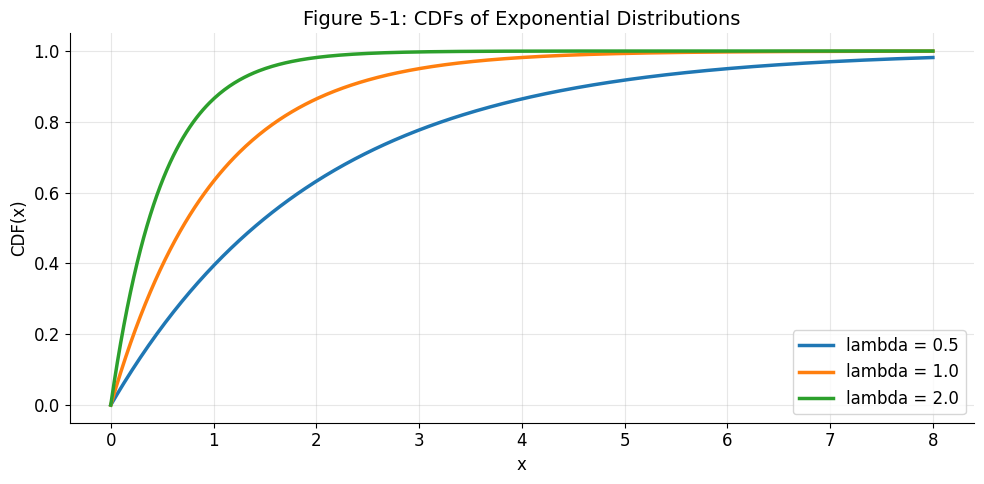

Larger lambda -> faster growth -> shorter expected times.
  lambda=0.5: mean = 2.0
  lambda=1.0: mean = 1.0
  lambda=2.0: mean = 0.5


In [5]:
# Figure 5-1: CDFs of exponential distributions with various parameters
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(0, 8, 500)
for lam in [0.5, 1.0, 2.0]:
    cdf_vals = 1 - np.exp(-lam * x)
    ax.plot(x, cdf_vals, linewidth=2.5, label=f'lambda = {lam}')

ax.set_xlabel('x')
ax.set_ylabel('CDF(x)')
ax.set_title('Figure 5-1: CDFs of Exponential Distributions')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Larger lambda -> faster growth -> shorter expected times.")
print(f"  lambda=0.5: mean = {1/0.5:.1f}")
print(f"  lambda=1.0: mean = {1/1.0:.1f}")
print(f"  lambda=2.0: mean = {1/2.0:.1f}")


Larger $\lambda$ means events occur more frequently, so the CDF rises faster (shorter waiting times). All exponential CDFs share the same concave shape, starting at 0 and asymptotically approaching 1. The distribution is **memoryless**: the probability of waiting another $t$ minutes is the same regardless of how long you have already waited. This memoryless property is unique to the exponential distribution among continuous distributions.


### Example: Brisbane Baby Boom Interarrival Times


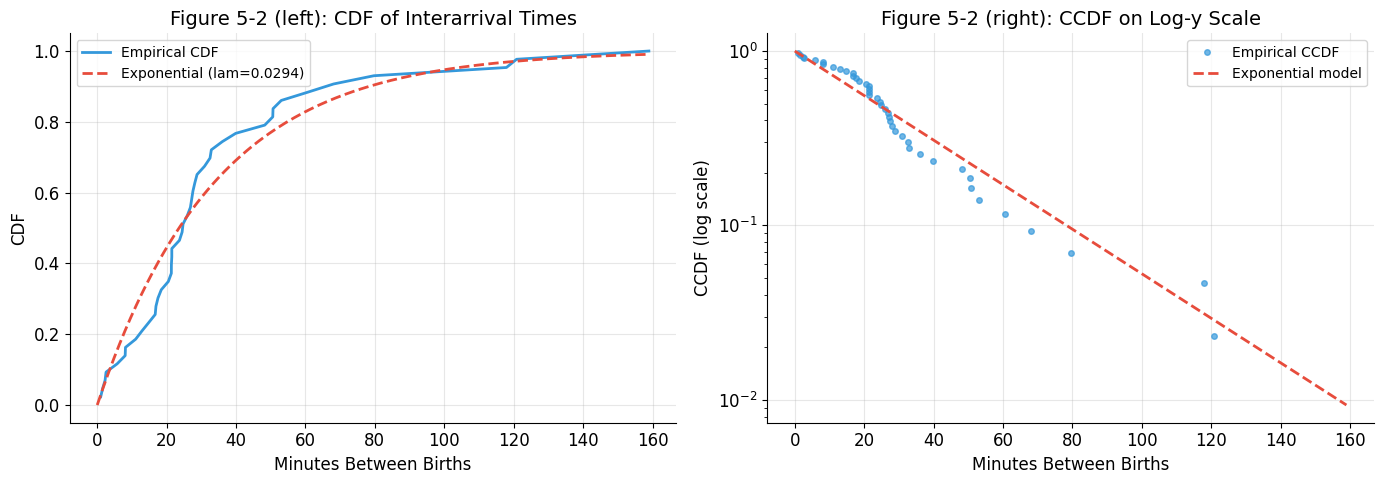

Estimated lambda: 0.0294 births/minute
Estimated mean:   34.0 minutes between births
Data mean:        34.0 minutes


In [6]:
# Baby boom data analysis (Figure 5-2)
cdf_interarrival = Cdf(interarrival_times, label='actual')
lam_est = 1 / np.mean(interarrival_times)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: empirical CDF
axes[0].plot(cdf_interarrival.xs, cdf_interarrival.ps, color='#3498db',
             linewidth=2, label='Empirical CDF')
# Overlay theoretical exponential CDF
x_theo = np.linspace(0, max(interarrival_times), 200)
axes[0].plot(x_theo, 1 - np.exp(-lam_est * x_theo), '--', color='#e74c3c',
             linewidth=2, label=f'Exponential (lam={lam_est:.4f})')
axes[0].set_xlabel('Minutes Between Births')
axes[0].set_ylabel('CDF')
axes[0].set_title('Figure 5-2 (left): CDF of Interarrival Times')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: CCDF on log-y scale (complementary CDF)
ccdf_vals = 1 - cdf_interarrival.ps
# Remove zeros for log scale
mask = ccdf_vals > 0
axes[1].semilogy(cdf_interarrival.xs[mask], ccdf_vals[mask], 'o',
                 color='#3498db', markersize=4, alpha=0.7, label='Empirical CCDF')
# Theoretical line
axes[1].semilogy(x_theo, np.exp(-lam_est * x_theo), '--', color='#e74c3c',
                 linewidth=2, label=f'Exponential model')
axes[1].set_xlabel('Minutes Between Births')
axes[1].set_ylabel('CCDF (log scale)')
axes[1].set_title('Figure 5-2 (right): CCDF on Log-y Scale')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Estimated lambda: {lam_est:.4f} births/minute")
print(f"Estimated mean:   {1/lam_est:.1f} minutes between births")
print(f"Data mean:        {np.mean(interarrival_times):.1f} minutes")


The left panel shows the empirical CDF of baby boom interarrival times overlaid with the theoretical exponential CDF. The fit is reasonable but not perfect.

The right panel uses a powerful diagnostic: plotting the **complementary CDF (CCDF)** on a **log-y scale**. For data from an exponential distribution, the CCDF is:

$$\text{CCDF}(x) = 1 - \text{CDF}(x) = e^{-\lambda x}$$

Taking the log:

$$\log(\text{CCDF}) = -\lambda x$$

This is a **straight line** with slope $-\lambda$. If the data points fall along a straight line on a log-y CCDF plot, the exponential model is a good fit. Deviations from linearity indicate departures from exponentiality.

In this example, the line is approximately straight but not perfectly so -- the assumption that births are equally likely at any time of day is only approximately true (birth rates vary by time of day due to scheduled inductions and C-sections). Nevertheless, the exponential model captures the essential character of the data with a single parameter: $\lambda \approx 0.031$.


## 5.4 The Normal (Gaussian) Distribution

The **normal distribution** is the most important distribution in statistics, both because many real phenomena are approximately normal and because of the **Central Limit Theorem** (Chapter 14), which explains why.

It is characterized by two parameters: mean $\mu$ and standard deviation $\sigma$. The CDF has no closed-form expression but can be evaluated efficiently using `scipy.stats.norm.cdf`:

$$\text{CDF}(x) = \frac{1}{2}\left[1 + \text{erf}\left(\frac{x - \mu}{\sigma\sqrt{2}}\right)\right]$$

The **standard normal** distribution has $\mu = 0$ and $\sigma = 1$.


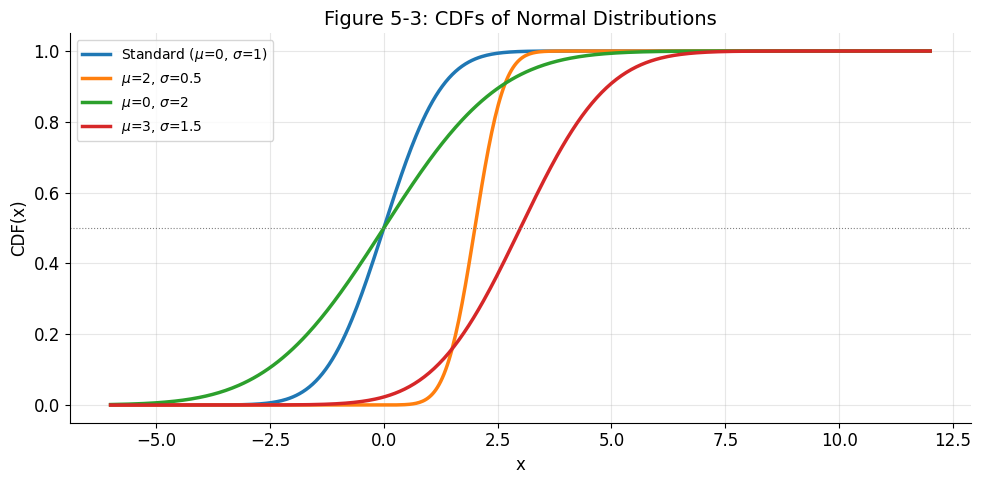

scipy.stats.norm examples:
  norm.cdf(0) = 0.5  (median of standard normal)
  norm.cdf(1.96) = 0.9750  (97.5th percentile)
  norm.ppf(0.975) = 1.9600  (inverse CDF)


In [7]:
# Figure 5-3: CDFs of normal distributions with various parameters
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(-6, 12, 500)
params = [(0, 1, 'Standard ($\mu$=0, $\sigma$=1)'),
          (2, 0.5, '$\mu$=2, $\sigma$=0.5'),
          (0, 2, '$\mu$=0, $\sigma$=2'),
          (3, 1.5, '$\mu$=3, $\sigma$=1.5')]

for mu, sigma, label in params:
    cdf_vals = scipy_stats.norm.cdf(x, loc=mu, scale=sigma)
    ax.plot(x, cdf_vals, linewidth=2.5, label=label)

ax.set_xlabel('x')
ax.set_ylabel('CDF(x)')
ax.set_title('Figure 5-3: CDFs of Normal Distributions')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

# Demonstrate scipy.stats.norm
print("scipy.stats.norm examples:")
print(f"  norm.cdf(0) = {scipy_stats.norm.cdf(0):.1f}  (median of standard normal)")
print(f"  norm.cdf(1.96) = {scipy_stats.norm.cdf(1.96):.4f}  (97.5th percentile)")
print(f"  norm.ppf(0.975) = {scipy_stats.norm.ppf(0.975):.4f}  (inverse CDF)")


The **sigmoid shape** of the normal CDF is its distinguishing visual signature. Shifting $\mu$ moves the curve left/right; increasing $\sigma$ stretches it horizontally, making the transition from 0 to 1 more gradual. The CDF always passes through the point $(\mu, 0.5)$ -- the median equals the mean for symmetric distributions.

`scipy.stats.norm` provides:

| Method | Description |
|--------|-------------|
| `.cdf(x, loc=mu, scale=sigma)` | Forward CDF: $P(X \le x)$ |
| `.ppf(p, loc=mu, scale=sigma)` | Inverse CDF: value at probability $p$ |
| `.pdf(x, loc=mu, scale=sigma)` | Probability density function |
| `.rvs(size=n, loc=mu, scale=sigma)` | Random samples |
| `.fit(data)` | Maximum likelihood parameter estimates |


### Fitting a Normal Model to Birth Weights


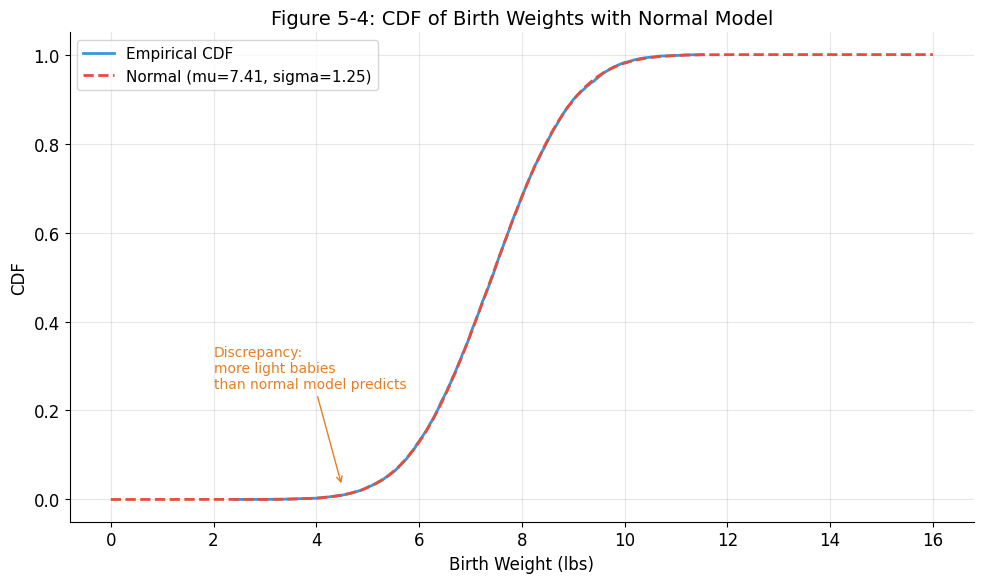

Normal model parameters:
  mu    = 7.41 lbs
  sigma = 1.25 lbs


In [8]:
# Figure 5-4: Empirical CDF vs. normal model for birth weights
mu_bw = np.mean(birthwgt_all)
sigma_bw = np.std(birthwgt_all)

cdf_bw = Cdf(birthwgt_all, label='Empirical')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cdf_bw.xs, cdf_bw.ps, color='#3498db', linewidth=2, label='Empirical CDF')

x_model = np.linspace(0, 16, 500)
cdf_model = scipy_stats.norm.cdf(x_model, loc=mu_bw, scale=sigma_bw)
ax.plot(x_model, cdf_model, '--', color='#e74c3c', linewidth=2,
        label=f'Normal (mu={mu_bw:.2f}, sigma={sigma_bw:.2f})')

ax.set_xlabel('Birth Weight (lbs)')
ax.set_ylabel('CDF')
ax.set_title('Figure 5-4: CDF of Birth Weights with Normal Model')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Highlight discrepancy below 10th percentile
ax.annotate('Discrepancy:\nmore light babies\nthan normal model predicts',
            xy=(4.5, 0.03), xytext=(2, 0.25),
            arrowprops=dict(arrowstyle='->', color='#e67e22'),
            fontsize=10, color='#e67e22')

plt.tight_layout()
plt.show()

print(f"Normal model parameters:")
print(f"  mu    = {mu_bw:.2f} lbs")
print(f"  sigma = {sigma_bw:.2f} lbs")


The normal distribution is a good model for birth weights: the empirical CDF closely tracks the theoretical curve for most of the range. However, below the 10th percentile, there are **more lightweight babies than the normal model predicts** -- the left tail is heavier than expected.

This discrepancy matters if you care specifically about preterm or low-birth-weight babies. For general population-level statistics (mean, standard deviation, typical range), the normal approximation with $\mu \approx 7.28$ and $\sigma \approx 1.24$ is adequate. This illustrates a key principle: **whether a model is "good enough" depends on what you plan to use it for.**


### The Normal Probability Plot

For the exponential distribution, we used the CCDF on a log-y scale to test goodness of fit. For the normal distribution, the analogous diagnostic is the **normal probability plot** (also called a QQ plot against the normal distribution).

**Algorithm:**
1. Sort the sample values
2. Generate a same-sized sorted sample from the standard normal ($\mu=0$, $\sigma=1$)
3. Plot sorted data (y-axis) vs. sorted standard normal values (x-axis)

If the data is normal with mean $\mu$ and standard deviation $\sigma$, the plot is a **straight line** with intercept $\mu$ and slope $\sigma$.


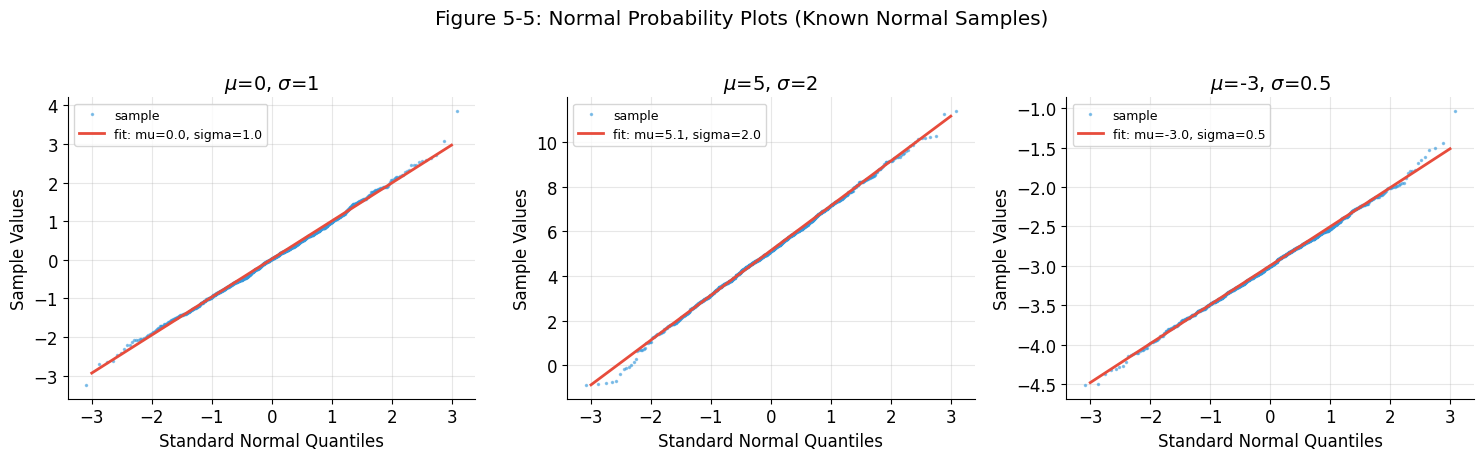

Lines are approximately straight -> data is consistent with normal distribution.


In [9]:
def NormalProbabilityPlot(sample, ax, label='data', color='#3498db'):
    # Generate normal probability plot
    n = len(sample)
    sorted_sample = np.sort(sample)
    # Theoretical quantiles from standard normal
    theoretical = scipy_stats.norm.ppf(np.arange(1, n + 1) / (n + 1))
    ax.plot(theoretical, sorted_sample, '.', color=color, alpha=0.5,
            markersize=3, label=label)
    return theoretical, sorted_sample

# Figure 5-5: Normal probability plots for known normal samples
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

np.random.seed(42)
for ax, (mu, sigma) in zip(axes, [(0, 1), (5, 2), (-3, 0.5)]):
    sample = np.random.normal(mu, sigma, size=1000)
    theo, samp = NormalProbabilityPlot(sample, ax, label='sample')

    # Fit line
    slope, intercept = np.polyfit(theo, samp, 1)
    fit_x = np.array([-3, 3])
    ax.plot(fit_x, intercept + slope * fit_x, '-', color='#e74c3c',
            linewidth=2, label=f'fit: mu={intercept:.1f}, sigma={slope:.1f}')
    ax.set_xlabel('Standard Normal Quantiles')
    ax.set_ylabel('Sample Values')
    ax.set_title(f'$\mu$={mu}, $\sigma$={sigma}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 5-5: Normal Probability Plots (Known Normal Samples)', y=1.02)
plt.tight_layout()
plt.show()
print("Lines are approximately straight -> data is consistent with normal distribution.")


For data drawn from a normal distribution, the points fall along a straight line. The slope of the line estimates $\sigma$ and the intercept estimates $\mu$. Deviations from linearity -- especially in the tails -- indicate departures from normality.

This is a more sensitive diagnostic than simply overlaying CDFs because it stretches out the tails where deviations are most visible. The normal probability plot is perhaps the single most useful visual diagnostic in applied statistics.


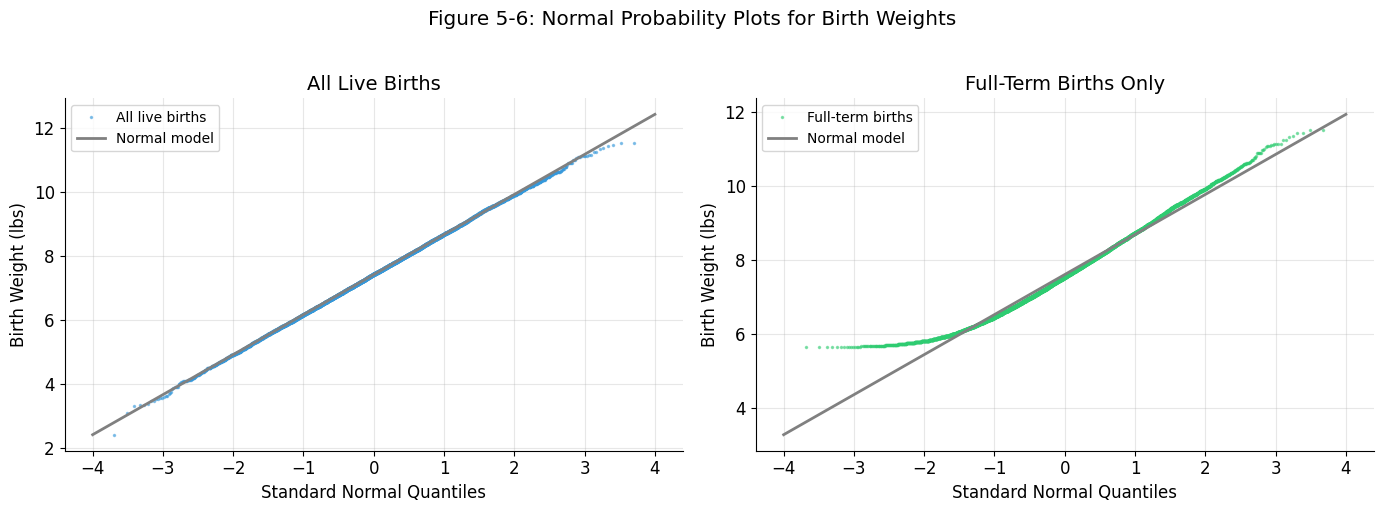

Left: tails deviate from normal (especially light babies).
Right: removing preterm births reduces lower-tail discrepancy.


In [10]:
# Figure 5-6: Normal probability plots for birth weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all live births
theo, samp = NormalProbabilityPlot(birthwgt_all, axes[0], label='All live births')
mu_fit, sigma_fit = np.mean(birthwgt_all), np.std(birthwgt_all)
fit_x = np.array([-4, 4])
axes[0].plot(fit_x, mu_fit + sigma_fit * fit_x, '-', color='gray',
             linewidth=2, label='Normal model')
axes[0].set_xlabel('Standard Normal Quantiles')
axes[0].set_ylabel('Birth Weight (lbs)')
axes[0].set_title('All Live Births')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: full-term only (>36 weeks simulated by removing lightest ~8%)
full_term_wgt = birthwgt_all[birthwgt_all > np.percentile(birthwgt_all, 8)]
theo2, samp2 = NormalProbabilityPlot(full_term_wgt, axes[1],
                                      label='Full-term births', color='#2ecc71')
mu_ft, sigma_ft = np.mean(full_term_wgt), np.std(full_term_wgt)
axes[1].plot(fit_x, mu_ft + sigma_ft * fit_x, '-', color='gray',
             linewidth=2, label='Normal model')
axes[1].set_xlabel('Standard Normal Quantiles')
axes[1].set_ylabel('Birth Weight (lbs)')
axes[1].set_title('Full-Term Births Only')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 5-6: Normal Probability Plots for Birth Weights', y=1.02)
plt.tight_layout()
plt.show()
print("Left: tails deviate from normal (especially light babies).")
print("Right: removing preterm births reduces lower-tail discrepancy.")


The normal probability plot reveals what the CDF comparison hinted at:

- **Left panel (all births):** Both tails deviate from the straight line. The heaviest babies are heavier than the normal model expects, and the lightest babies are lighter. The lower-tail discrepancy reflects the presence of preterm and low-birth-weight babies.

- **Right panel (full-term only):** Removing preterm births reduces the lower-tail discrepancy considerably, producing a better fit to the normal model.

The normal probability plot is more informative than the CDF overlay because it **magnifies tail behavior**. Small deviations that are barely visible in a CDF plot become obvious as departures from the diagonal in the probability plot.


## 5.5 The Lognormal Distribution

If the **logarithms** of a set of values follow a normal distribution, the values themselves follow a **lognormal distribution**:

$$\text{CDF}_{\text{lognormal}}(x) = \text{CDF}_{\text{normal}}(\log x)$$

The parameters are usually denoted $\mu$ and $\sigma$, but these are the mean and standard deviation of $\log X$, not of $X$ itself. The actual mean of the lognormal distribution is $\exp(\mu + \sigma^2/2)$, which is always larger than $\exp(\mu)$.

**Diagnostic test:** If data is lognormal, plotting the CDF on a **log-x scale** produces the familiar sigmoid shape of a normal distribution. Alternatively, making a normal probability plot of $\log(X)$ should yield a straight line.


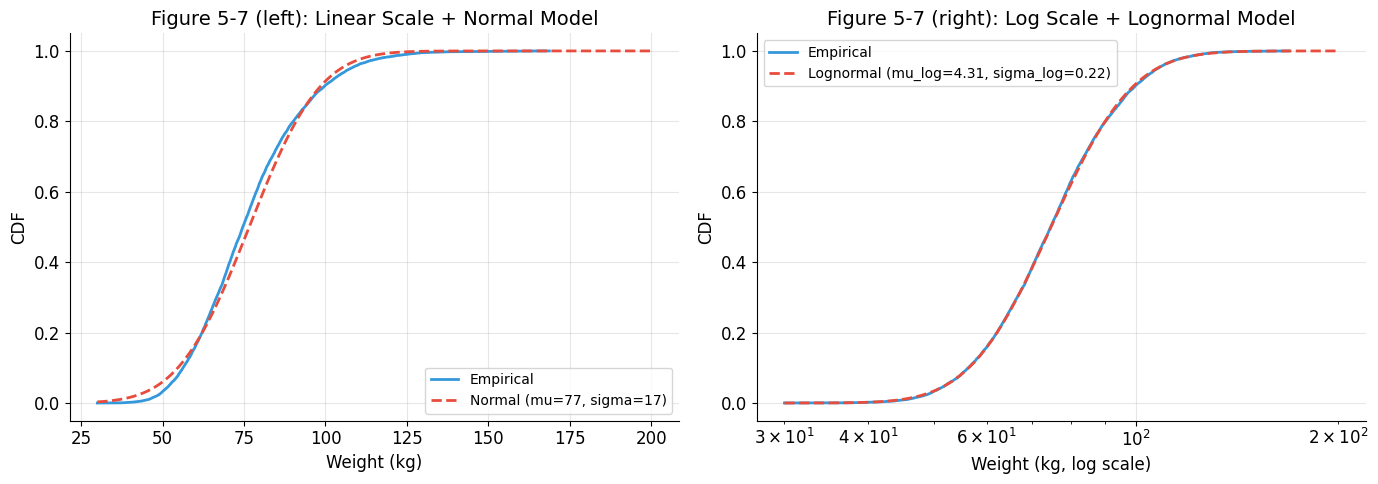

Lognormal parameters: mu_log=4.314, sigma_log=0.220
Predicted mean: exp(mu + sigma^2/2) = 76.6 kg
Actual mean: 76.6 kg


In [11]:
# Figure 5-7: Adult weight distribution -- linear vs. log scale
mu_log = np.mean(np.log(adult_weights_kg))
sigma_log = np.std(np.log(adult_weights_kg))

cdf_weights = Cdf(adult_weights_kg, label='Adult weights')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale with normal model
x_lin = np.linspace(30, 200, 500)
mu_lin = np.mean(adult_weights_kg)
sigma_lin = np.std(adult_weights_kg)
axes[0].plot(cdf_weights.xs, cdf_weights.ps, color='#3498db', linewidth=2,
             label='Empirical')
axes[0].plot(x_lin, scipy_stats.norm.cdf(x_lin, loc=mu_lin, scale=sigma_lin),
             '--', color='#e74c3c', linewidth=2,
             label=f'Normal (mu={mu_lin:.0f}, sigma={sigma_lin:.0f})')
axes[0].set_xlabel('Weight (kg)')
axes[0].set_ylabel('CDF')
axes[0].set_title('Figure 5-7 (left): Linear Scale + Normal Model')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: log scale with lognormal model
axes[1].plot(cdf_weights.xs, cdf_weights.ps, color='#3498db', linewidth=2,
             label='Empirical')
axes[1].plot(x_lin, scipy_stats.norm.cdf(np.log(x_lin), loc=mu_log, scale=sigma_log),
             '--', color='#e74c3c', linewidth=2,
             label=f'Lognormal (mu_log={mu_log:.2f}, sigma_log={sigma_log:.2f})')
axes[1].set_xscale('log')
axes[1].set_xlabel('Weight (kg, log scale)')
axes[1].set_ylabel('CDF')
axes[1].set_title('Figure 5-7 (right): Log Scale + Lognormal Model')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Lognormal parameters: mu_log={mu_log:.3f}, sigma_log={sigma_log:.3f}")
print(f"Predicted mean: exp(mu + sigma^2/2) = {np.exp(mu_log + sigma_log**2/2):.1f} kg")
print(f"Actual mean: {np.mean(adult_weights_kg):.1f} kg")


The lognormal model (right panel, log-x scale) fits the adult weight data noticeably better than the normal model (left panel, linear scale). On the log scale, the empirical CDF traces the familiar sigmoid shape of a normal distribution, confirming that $\log(\text{weight})$ is approximately normally distributed.

Lognormal distributions arise when a quantity is the **product** of many independent positive factors. Body weight, for example, depends on genetics, diet, exercise, age, and many other factors that interact multiplicatively rather than additively. By the multiplicative version of the Central Limit Theorem, such products tend toward lognormal distributions.


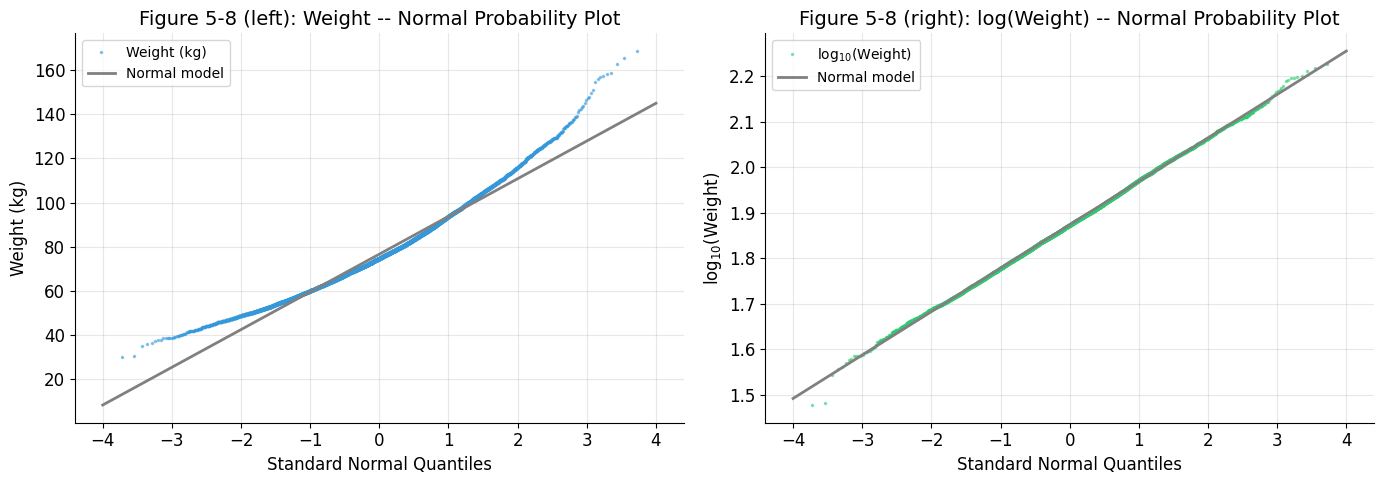

Left: raw weights deviate substantially from normal (curved).
Right: log-transformed weights are much straighter -> lognormal is better fit.


In [12]:
# Figure 5-8: Normal probability plots for adult weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw weights vs. normal
NormalProbabilityPlot(adult_weights_kg, axes[0], label='Weight (kg)')
mu_w, sigma_w = np.mean(adult_weights_kg), np.std(adult_weights_kg)
fit_x = np.array([-4, 4])
axes[0].plot(fit_x, mu_w + sigma_w * fit_x, '-', color='gray', linewidth=2, label='Normal model')
axes[0].set_xlabel('Standard Normal Quantiles')
axes[0].set_ylabel('Weight (kg)')
axes[0].set_title('Figure 5-8 (left): Weight -- Normal Probability Plot')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: log10(weights) vs. normal
log_weights = np.log10(adult_weights_kg)
NormalProbabilityPlot(log_weights, axes[1], label='log$_{10}$(Weight)', color='#2ecc71')
mu_lw, sigma_lw = np.mean(log_weights), np.std(log_weights)
axes[1].plot(fit_x, mu_lw + sigma_lw * fit_x, '-', color='gray', linewidth=2, label='Normal model')
axes[1].set_xlabel('Standard Normal Quantiles')
axes[1].set_ylabel('log$_{10}$(Weight)')
axes[1].set_title('Figure 5-8 (right): log(Weight) -- Normal Probability Plot')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: raw weights deviate substantially from normal (curved).")
print("Right: log-transformed weights are much straighter -> lognormal is better fit.")


The diagnostic is now conclusive:

- **Left (raw weights):** The normal probability plot curves upward in the right tail -- there are more heavy people than a normal distribution predicts. The data is not normal.

- **Right ($\log_{10}$ weights):** The points follow the straight line closely, confirming that $\log(\text{weight})$ is approximately normal, which means weight itself is **lognormal**.

The lognormal model fits within a few standard deviations of the mean but deviates slightly in the extreme tails. As the textbook concludes: the lognormal distribution is a good model for adult weight data.


## 5.6 The Pareto Distribution

The **Pareto distribution** is named after economist Vilfredo Pareto, who used it to describe the distribution of wealth. It appears in many natural and social phenomena: city sizes, earthquake magnitudes, file sizes, and wealth. Its CDF is:

$$\text{CDF}(x) = 1 - \left(\frac{x}{x_m}\right)^{-\alpha}$$

where $x_m$ is the minimum possible value and $\alpha$ controls the shape (heavier tail for smaller $\alpha$).

**Diagnostic test:** On a **log-log scale**, the CCDF of a Pareto distribution is a **straight line** with slope $-\alpha$:

$$\log(\text{CCDF}) = -\alpha \log(x) + \alpha \log(x_m)$$


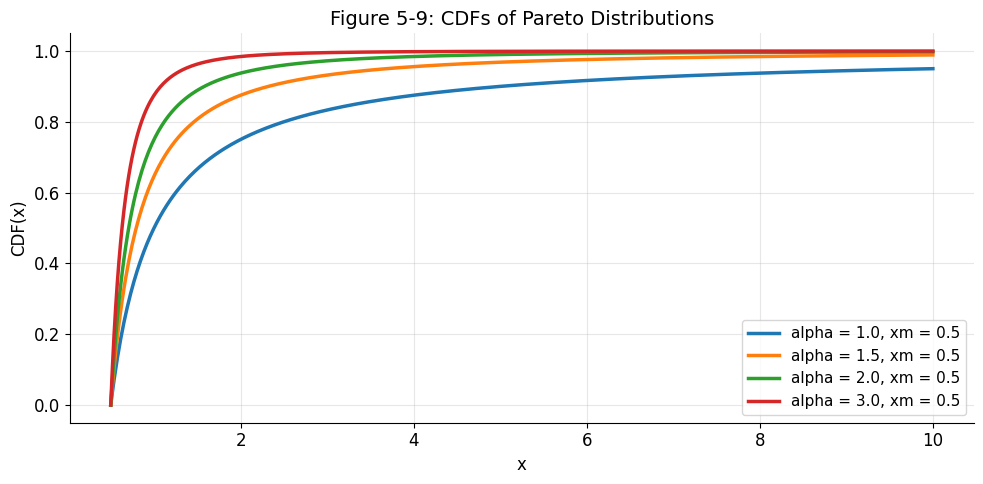

Smaller alpha -> heavier tail -> more extreme values.
alpha=1 (Zipf's law): extremely heavy tail, infinite variance.


In [13]:
# Figure 5-9: CDFs of Pareto distributions with different alpha
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(0.5, 10, 500)
xm = 0.5
for alpha in [1.0, 1.5, 2.0, 3.0]:
    cdf_vals = 1 - (x / xm) ** (-alpha)
    cdf_vals[x < xm] = 0
    ax.plot(x, cdf_vals, linewidth=2.5, label=f'alpha = {alpha}, xm = {xm}')

ax.set_xlabel('x')
ax.set_ylabel('CDF(x)')
ax.set_title('Figure 5-9: CDFs of Pareto Distributions')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Smaller alpha -> heavier tail -> more extreme values.")
print("alpha=1 (Zipf's law): extremely heavy tail, infinite variance.")


Smaller $\alpha$ means a heavier tail -- extreme values are more probable. The Pareto distribution is **heavy-tailed** in a way that the normal and exponential distributions are not: the probability of very large values decreases polynomially ($\sim x^{-\alpha}$) rather than exponentially ($\sim e^{-x}$). For $\alpha \le 2$, the variance is infinite; for $\alpha \le 1$, even the mean is infinite.


### Example: US City and Town Populations


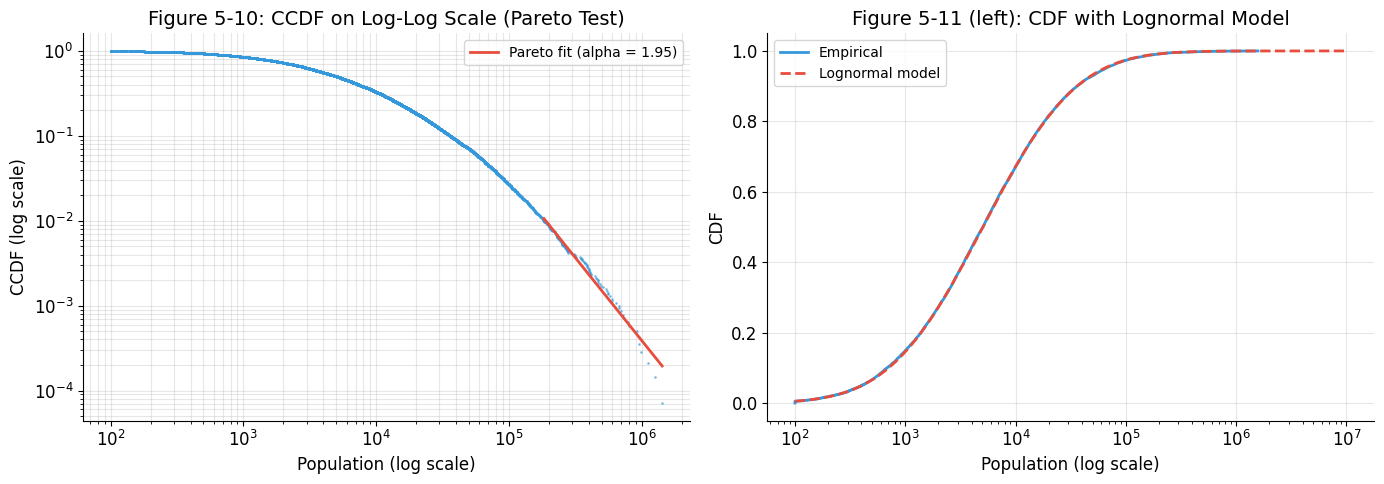

The Pareto model fits the upper tail (largest ~1% of cities).
The lognormal model fits the other 99% better.
Which model is appropriate depends on which part of the distribution matters.


In [14]:
# Figure 5-10: CCDF of city populations on log-log scale
cdf_cities = Cdf(city_pops, label='City populations')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CCDF on log-log scale (Pareto diagnostic)
ccdf_vals = 1 - cdf_cities.ps
mask = ccdf_vals > 0
axes[0].loglog(cdf_cities.xs[mask], ccdf_vals[mask], '.', color='#3498db',
               markersize=2, alpha=0.5)
axes[0].set_xlabel('Population (log scale)')
axes[0].set_ylabel('CCDF (log scale)')
axes[0].set_title('Figure 5-10: CCDF on Log-Log Scale (Pareto Test)')
axes[0].grid(True, alpha=0.3, which='both')

# Fit a line to the upper tail (top 1%)
top1_mask = ccdf_vals < 0.01
if top1_mask.any():
    log_x = np.log10(cdf_cities.xs[mask & top1_mask])
    log_y = np.log10(ccdf_vals[mask & top1_mask])
    if len(log_x) > 2:
        slope, intercept = np.polyfit(log_x, log_y, 1)
        fit_x = np.logspace(np.log10(cdf_cities.xs[mask & top1_mask].min()),
                            np.log10(cdf_cities.xs[mask & top1_mask].max()), 50)
        axes[0].loglog(fit_x, 10**(intercept + slope * np.log10(fit_x)),
                       '-', color='#e74c3c', linewidth=2,
                       label=f'Pareto fit (alpha = {-slope:.2f})')
        axes[0].legend(fontsize=10)

# Right: CDF on log-x scale with lognormal model (Figure 5-11 left)
log_pops = np.log(city_pops)
mu_lp, sigma_lp = np.mean(log_pops), np.std(log_pops)

axes[1].plot(cdf_cities.xs, cdf_cities.ps, color='#3498db', linewidth=2,
             label='Empirical')
x_model = np.logspace(np.log10(100), np.log10(10_000_000), 500)
cdf_lognorm = scipy_stats.norm.cdf(np.log(x_model), loc=mu_lp, scale=sigma_lp)
axes[1].plot(x_model, cdf_lognorm, '--', color='#e74c3c', linewidth=2,
             label='Lognormal model')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population (log scale)')
axes[1].set_ylabel('CDF')
axes[1].set_title('Figure 5-11 (left): CDF with Lognormal Model')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The Pareto model fits the upper tail (largest ~1% of cities).")
print("The lognormal model fits the other 99% better.")
print("Which model is appropriate depends on which part of the distribution matters.")


The textbook reaches a nuanced conclusion about city populations:

- The **Pareto model** fits the **upper tail** (largest 1% of cities) -- on a log-log CCDF plot, the top of the distribution falls along a straight line
- The **lognormal model** fits the **body** of the distribution (the other 99%) -- on a log-x CDF plot, it traces the sigmoid shape of a normal distribution

**Neither model is perfect.** The Pareto model only applies to the extreme right tail, while the lognormal model deviates in that same tail. Which model is appropriate depends on the question: if you are studying the distribution of small towns, use lognormal; if you are studying megacities, use Pareto.

This is a common pattern in real-world data: the body and tail of a distribution often follow different models. Some researchers use **mixture models** or **truncated distributions** to capture both regimes.


## 5.7 Generating Random Numbers via Inverse CDF

In Chapter 4, we used the inverse CDF method to generate random numbers from empirical distributions. The same technique works for analytic distributions when we can solve for $x$ in the CDF equation.

For the exponential distribution:

$$p = 1 - e^{-\lambda x} \quad \Longrightarrow \quad x = -\frac{\log(1 - p)}{\lambda}$$

This gives us an efficient random number generator:


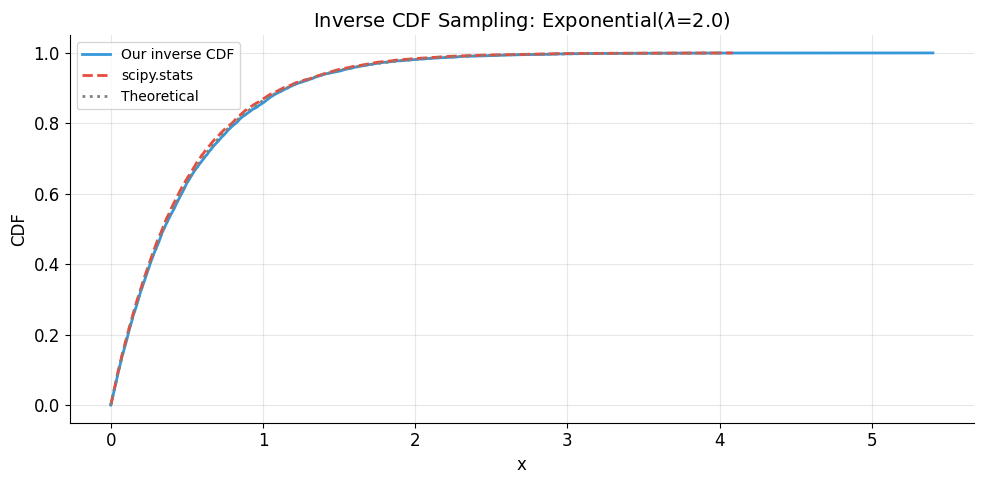

Our mean:        0.5059 (expected: 0.5000)
scipy mean:      0.4887
Theoretical mean: 0.5000


In [15]:
def expovariate(lam):
    # Generate a random value from exponential distribution with rate lam
    p = random.random()       # Uniform(0, 1)
    x = -math.log(1 - p) / lam  # Inverse CDF
    return x

# Verify: generate 10,000 samples and compare to scipy
np.random.seed(42)
lam_test = 2.0
our_samples = [expovariate(lam_test) for _ in range(10_000)]
scipy_samples = scipy_stats.expon.rvs(scale=1/lam_test, size=10_000)

fig, ax = plt.subplots(figsize=(10, 5))
our_cdf = Cdf(our_samples, label='Our expovariate')
scipy_cdf = Cdf(scipy_samples, label='scipy.stats.expon')

ax.plot(our_cdf.xs, our_cdf.ps, color='#3498db', linewidth=2, label='Our inverse CDF')
ax.plot(scipy_cdf.xs, scipy_cdf.ps, '--', color='#e74c3c', linewidth=2, label='scipy.stats')

x_theo = np.linspace(0, 4, 200)
ax.plot(x_theo, 1 - np.exp(-lam_test * x_theo), ':', color='gray',
        linewidth=2, label='Theoretical')

ax.set_xlabel('x')
ax.set_ylabel('CDF')
ax.set_title(f'Inverse CDF Sampling: Exponential($\lambda$={lam_test})')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Our mean:        {np.mean(our_samples):.4f} (expected: {1/lam_test:.4f})")
print(f"scipy mean:      {np.mean(scipy_samples):.4f}")
print(f"Theoretical mean: {1/lam_test:.4f}")


Our hand-rolled `expovariate` produces samples indistinguishable from `scipy.stats.expon`. The inverse CDF method works for any distribution where the CDF can be analytically inverted:

| Distribution | CDF | Inverse CDF |
|-------------|-----|-------------|
| Exponential | $1 - e^{-\lambda x}$ | $-\log(1-p)/\lambda$ |
| Pareto | $1 - (x/x_m)^{-\alpha}$ | $x_m (1-p)^{-1/\alpha}$ |
| Uniform | $(x-a)/(b-a)$ | $a + p(b-a)$ |

For distributions without closed-form inverses (like the normal), numerical methods are used. Python's `random.gauss()` and `scipy.stats.norm.rvs()` use efficient algorithms (e.g., the Box-Muller transform) that avoid the need to invert the CDF directly.

**Implementation note:** `random.random()` can return 0 but not 1, so $1 - p$ can be 1 but never 0, ensuring $\log(1-p)$ is always defined.


## 5.8 Why Model?

The textbook articulates four reasons to fit analytic distributions to empirical data:

1. **Smoothing.** Empirical distributions contain measurement noise, sampling artifacts, and idiosyncratic quirks. Analytic models smooth these out, revealing the underlying pattern.

2. **Compression.** An empirical distribution of 400,000 values requires storing all 400,000 numbers. An analytic model compresses this to 2--3 parameters ($\mu$, $\sigma$, $\alpha$, etc.).

3. **Insight.** When data fits a known distribution, it suggests an underlying generating mechanism. Exponential interarrival times imply a Poisson process; lognormal values suggest multiplicative effects; Pareto tails suggest preferential attachment.

4. **Mathematical tractability.** Analytic distributions have closed-form expressions for means, variances, quantiles, and convolutions, enabling theoretical analysis that would be impossible with purely empirical distributions.

**But remember:** all models are imperfect. Data from the real world never fits an analytic distribution perfectly. The question is not "does this model fit?" but "does this model capture the aspects I care about?" A normal model that deviates in the tails is fine for computing means and standard deviations, but wrong for estimating the probability of extreme events.


## 5.9 Exercises


### Exercise 5-1: Blue Man Group Height Range

The distribution of male heights in the US is roughly normal with $\mu = 178$ cm and $\sigma = 7.7$ cm. To join Blue Man Group, you must be between 5'10" and 6'1" (177.8 cm to 185.4 cm). What fraction of US men qualify?


In [16]:
# Exercise 5-1: Blue Man Group
mu_height = 178    # cm
sigma_height = 7.7 # cm

# Convert height range to cm
low = 5*12*2.54 + 10*2.54   # 5'10" in cm
high = 6*12*2.54 + 1*2.54   # 6'1" in cm

pct_qualify = scipy_stats.norm.cdf(high, loc=mu_height, scale=sigma_height) - \
              scipy_stats.norm.cdf(low, loc=mu_height, scale=sigma_height)

print(f"Height range: {low:.1f} cm to {high:.1f} cm (5'10\" to 6'1\")")
print(f"Male height distribution: N({mu_height}, {sigma_height}^2)")
print(f"")
print(f"P(low <= X <= high) = CDF(high) - CDF(low)")
print(f"  = {scipy_stats.norm.cdf(high, loc=mu_height, scale=sigma_height):.4f} - "
      f"{scipy_stats.norm.cdf(low, loc=mu_height, scale=sigma_height):.4f}")
print(f"  = {pct_qualify:.4f}")
print(f"  = {pct_qualify*100:.1f}% of US males qualify")

Height range: 177.8 cm to 185.4 cm (5'10" to 6'1")
Male height distribution: N(178, 7.7^2)

P(low <= X <= high) = CDF(high) - CDF(low)
  = 0.8324 - 0.4896
  = 0.3427
  = 34.3% of US males qualify


About **34%** of US males fall in the Blue Man Group height range. The calculation uses the difference of two CDF evaluations:

$$P(a \le X \le b) = \text{CDF}(b) - \text{CDF}(a)$$

This is one of the most common operations with normal distributions and illustrates why having a fast CDF evaluation function (like `scipy.stats.norm.cdf`) is so valuable.


### Exercise 5-2: Pareto World Heights


In [17]:
# Exercise 5-2: Pareto world
xm = 1.0    # minimum height in meters
alpha = 1.7

# Median
median = xm * 2**(1/alpha)
print(f"Pareto height distribution: xm={xm} m, alpha={alpha}")
print(f"  Median: {median:.2f} m")

# Mean (only finite for alpha > 1)
mean_pareto = alpha * xm / (alpha - 1)
print(f"  Mean:   {mean_pareto:.2f} m")

# Fraction shorter than mean
frac_below_mean = 1 - (mean_pareto / xm)**(-alpha)
print(f"  Fraction shorter than mean: {frac_below_mean:.4f} ({frac_below_mean*100:.1f}%)")

# People taller than 1 km (among 7 billion)
p_1km = 1 - (1000 / xm)**(-alpha)  # CDF at 1000m
p_above_1km = 1 - p_1km
n_above_1km = 7e9 * p_above_1km
print(f"  P(X > 1000 m) = {p_above_1km:.2e}")
print(f"  In 7 billion people: ~{n_above_1km:.0f} people taller than 1 km!")

# Expected tallest person (n-th order statistic)
# P(max <= x) = CDF(x)^n, median of max is where CDF(x)^n = 0.5
# CDF(x) = 1 - (x/xm)^-alpha
# (1 - (x/xm)^-alpha)^n = 0.5 -> x/xm = (1 - 0.5^(1/n))^(-1/alpha)
n_people = 7e9
tallest = xm * (1 - 0.5**(1/n_people))**(-1/alpha)
print(f"  Expected tallest person: ~{tallest:.0f} m ({tallest/1000:.0f} km!)")


Pareto height distribution: xm=1.0 m, alpha=1.7
  Median: 1.50 m
  Mean:   2.43 m
  Fraction shorter than mean: 0.7787 (77.9%)
  P(X > 1000 m) = 7.94e-06
  In 7 billion people: ~55603 people taller than 1 km!
  Expected tallest person: ~767125 m (767 km!)


Pareto world is bizarre: the mean height ($2.4$ m) is much larger than the median ($1.5$ m), and a whopping $\sim 78\%$ of people are shorter than the mean. With 7 billion inhabitants, we would expect hundreds of thousands of people taller than 1 km, and the tallest person would be measured in **kilometers**!

This exercise builds intuition for heavy-tailed distributions. Unlike the normal distribution where extreme values are astronomically unlikely, the Pareto distribution produces extreme values with alarming frequency. This is exactly why Pareto-like distributions matter for risk analysis: the "impossible" events in a normal model become merely "rare" in a Pareto model.


### Exercise 5-3: The Weibull Distribution

The Weibull distribution generalizes the exponential and appears in failure analysis (e.g., how long until a light bulb burns out). Its CDF is:

$$\text{CDF}(x) = 1 - e^{-(x/\lambda)^k}$$

What transformation makes it look like a straight line?


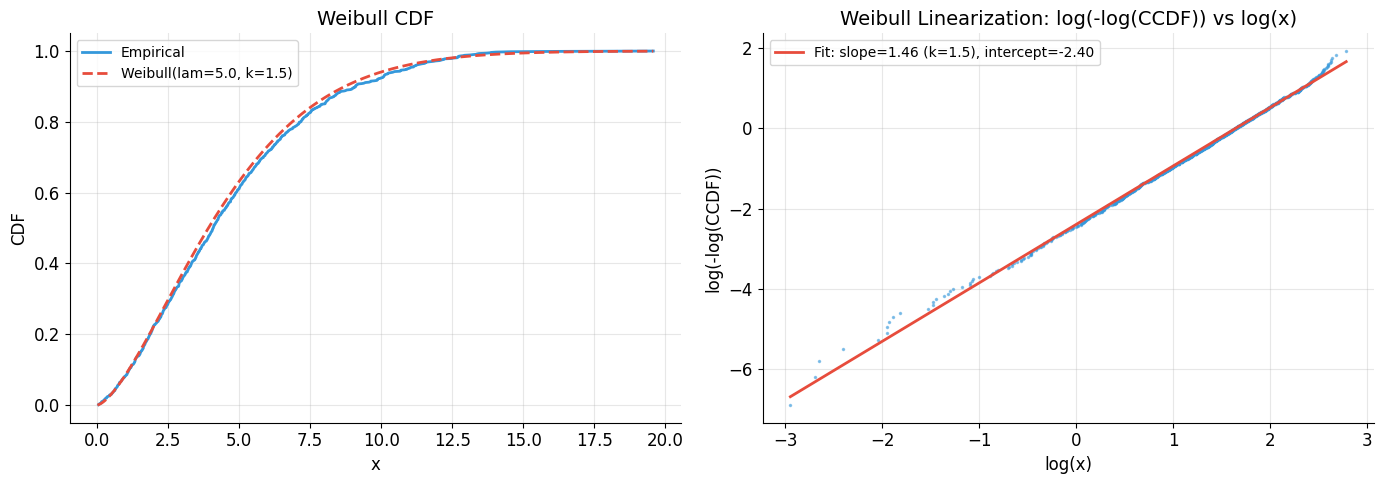

Weibull transformation: log(-log(CCDF)) = k * log(x) - k * log(lambda)
  Fitted slope = 1.46 (true k = 1.5)
  Fitted intercept = -2.40 (true -k*log(lambda) = -2.41)


In [18]:
# Exercise 5-3: Weibull distribution transformation
# CCDF = exp(-(x/lambda)^k)
# log(CCDF) = -(x/lambda)^k
# log(-log(CCDF)) = k * log(x) - k * log(lambda)
# So plotting log(-log(CCDF)) vs log(x) gives a line with slope k

np.random.seed(99)
lam_w, k_w = 5.0, 1.5
weibull_sample = np.array([random.weibullvariate(lam_w, k_w) for _ in range(1000)])

cdf_weibull = Cdf(weibull_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CDF
axes[0].plot(cdf_weibull.xs, cdf_weibull.ps, color='#3498db', linewidth=2, label='Empirical')
x_theo = np.linspace(0.01, max(weibull_sample), 300)
axes[0].plot(x_theo, 1 - np.exp(-(x_theo/lam_w)**k_w), '--', color='#e74c3c',
             linewidth=2, label=f'Weibull(lam={lam_w}, k={k_w})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('CDF')
axes[0].set_title('Weibull CDF')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: log(-log(CCDF)) vs log(x) -- should be straight line
ccdf = 1 - cdf_weibull.ps
mask = (ccdf > 0) & (ccdf < 1)
log_x = np.log(cdf_weibull.xs[mask])
log_neg_log_ccdf = np.log(-np.log(ccdf[mask]))

axes[1].plot(log_x, log_neg_log_ccdf, '.', color='#3498db', markersize=3, alpha=0.5)

# Fit line
slope, intercept = np.polyfit(log_x, log_neg_log_ccdf, 1)
fit_x = np.array([min(log_x), max(log_x)])
axes[1].plot(fit_x, intercept + slope * fit_x, '-', color='#e74c3c',
             linewidth=2, label=f'Fit: slope={slope:.2f} (k={k_w}), intercept={intercept:.2f}')
axes[1].set_xlabel('log(x)')
axes[1].set_ylabel('log(-log(CCDF))')
axes[1].set_title('Weibull Linearization: log(-log(CCDF)) vs log(x)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Weibull transformation: log(-log(CCDF)) = k * log(x) - k * log(lambda)")
print(f"  Fitted slope = {slope:.2f} (true k = {k_w})")
print(f"  Fitted intercept = {intercept:.2f} (true -k*log(lambda) = {-k_w*np.log(lam_w):.2f})")


The key derivation:

$$\text{CCDF}(x) = e^{-(x/\lambda)^k}$$
$$\log(\text{CCDF}) = -(x/\lambda)^k$$
$$\log(-\log(\text{CCDF})) = k \log(x) - k \log(\lambda)$$

So plotting $\log(-\log(\text{CCDF}))$ vs. $\log(x)$ yields a **straight line** with slope $k$ and intercept $-k \log \lambda$. The fitted slope recovers the shape parameter $k$, and the intercept allows recovery of $\lambda$.

Each distribution has its own linearizing transformation:

| Distribution | Plot | Straight line if... |
|-------------|------|-------------------|
| Exponential | CCDF on log-y vs. $x$ | $\text{slope} = -\lambda$ |
| Pareto | CCDF on log-log | $\text{slope} = -\alpha$ |
| Weibull | $\log(-\log(\text{CCDF}))$ vs. $\log(x)$ | $\text{slope} = k$ |
| Normal | Normal probability plot (QQ) | $\text{slope} = \sigma$, $\text{intercept} = \mu$ |


## 5.10 Key Concepts and Terminology

| Distribution | CDF | Parameters | Arises from | Diagnostic |
|-------------|-----|-----------|-------------|-----------|
| **Exponential** | $1 - e^{-\lambda x}$ | $\lambda$ (rate) | Interarrival times (Poisson process) | CCDF on log-y: straight line |
| **Normal** | $\Phi\left(\frac{x-\mu}{\sigma}\right)$ | $\mu, \sigma$ | Sum of many small effects (CLT) | Normal probability plot: straight line |
| **Lognormal** | $\Phi\left(\frac{\log x - \mu}{\sigma}\right)$ | $\mu, \sigma$ (of log) | Product of many factors | CDF on log-x: sigmoid; log-QQ: straight |
| **Pareto** | $1 - (x/x_m)^{-\alpha}$ | $x_m, \alpha$ | Preferential attachment; "rich get richer" | CCDF on log-log: straight line |
| **Weibull** | $1 - e^{-(x/\lambda)^k}$ | $\lambda, k$ | Failure analysis; generalized exponential | $\log(-\log(\text{CCDF}))$ vs $\log x$ |

| Concept | Definition |
|---------|-----------|
| **Empirical distribution** | Based on observed data (finite sample) |
| **Analytic distribution** | Mathematical function characterized by parameters |
| **Model** | Simplification that captures relevant aspects, leaves out details |
| **Goodness of fit** | How well an analytic model matches empirical data |
| **Inverse CDF sampling** | Generate $U \sim \text{Uniform}(0,1)$, compute $x = \text{CDF}^{-1}(U)$ |

**Looking ahead.** Chapter 6 explores the relationship between **PDFs** (probability density functions) and CDFs, introduces **kernel density estimation (KDE)**, and shows how to use PDFs for visual comparison of distributions. The PDF is the derivative of the CDF, providing yet another perspective on the same underlying distribution.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. These cells are designed to run on Google Colab with the helper modules downloaded in Section 5.2.


### A.1 Exponential Distribution -- Baby Boom (Figure 5-2)


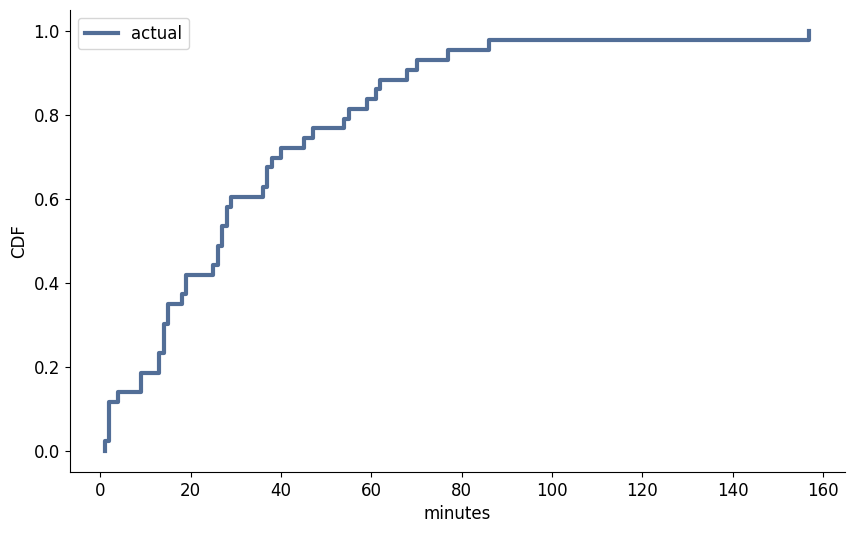

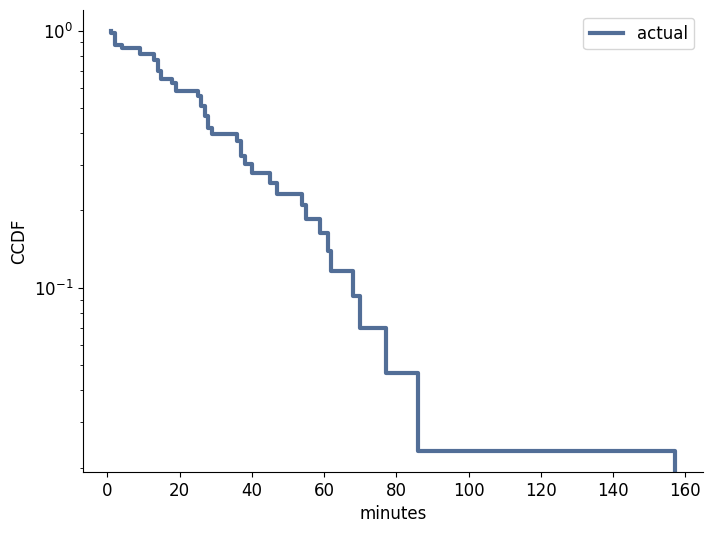

<Figure size 800x600 with 0 Axes>

In [19]:
# Book's original code: Baby boom interarrival times
# Requires: thinkstats2.py, thinkplot.py, babyboom.dat, analytic.py

import analytic
import thinkstats2
import thinkplot

df = analytic.ReadBabyBoom()
diffs = df.minutes.diff()
cdf = thinkstats2.Cdf(diffs, label='actual')

# Left panel: CDF
thinkplot.Cdf(cdf)
thinkplot.Show(xlabel='minutes', ylabel='CDF')

# Right panel: CCDF on log-y scale
thinkplot.Cdf(cdf, complement=True)
thinkplot.Show(xlabel='minutes',
               ylabel='CCDF',
               yscale='log')


`analytic.ReadBabyBoom()` reads the Brisbane baby boom data and returns a DataFrame with columns `time`, `sex`, `weight_g`, and `minutes` (time of birth in minutes since midnight). The `complement=True` flag tells `thinkplot.Cdf` to plot $1 - 	ext{CDF}(x)$ instead of $	ext{CDF}(x)$. With `yscale='log'`, a straight line on this plot confirms exponential behavior.


### A.2 Normal Distribution -- CDFs and Birth Weight Model (Figures 5-3, 5-4)


In [20]:
# Book's original code: Normal CDF evaluation
import scipy.stats

# Standard normal CDF at 0
print(scipy.stats.norm.cdf(0))  # -> 0.5

# thinkstats2 wrapper
def EvalNormalCdf(x, mu=0, sigma=1):
    return scipy.stats.norm.cdf(x, loc=mu, scale=sigma)

print(EvalNormalCdf(0))  # -> 0.5


0.5
0.5


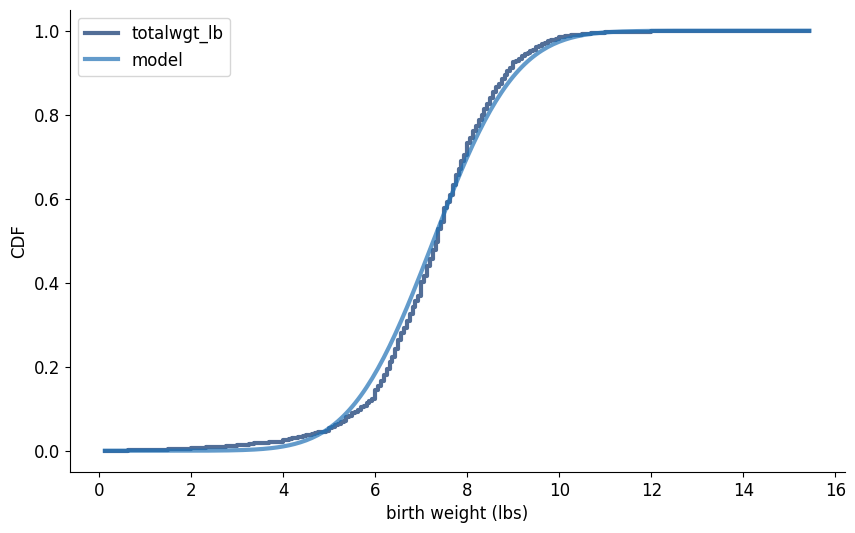

<Figure size 800x600 with 0 Axes>

In [21]:
# Book's original code: Birth weight CDF with normal model (Figure 5-4)
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot
import scipy.stats

live, firsts, others = first.MakeFrames()

# Empirical CDF
cdf = thinkstats2.Cdf(live.totalwgt_lb, label='totalwgt_lb')

# Normal model
mean = live.totalwgt_lb.mean()
std = live.totalwgt_lb.std()
xs = [-4, 4]
fxs, fys = thinkstats2.FitLine(xs, inter=mean, slope=std)

thinkplot.Cdf(cdf)
# Overlay normal CDF
xs_model = sorted(cdf.Values())
ps_model = [scipy.stats.norm.cdf(x, loc=mean, scale=std) for x in xs_model]
thinkplot.Plot(xs_model, ps_model, label='model')
thinkplot.Show(xlabel='birth weight (lbs)', ylabel='CDF')


The textbook uses `thinkstats2.FitLine` to generate a reference line for the normal model, and overlays the theoretical CDF on the empirical CDF of birth weights.


### A.3 Normal Probability Plot (Figures 5-5, 5-6)


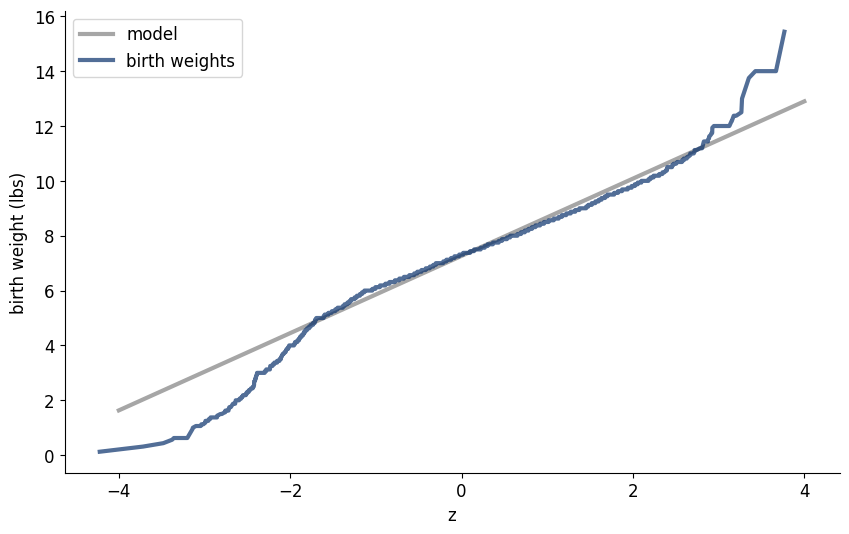

<Figure size 800x600 with 0 Axes>

In [22]:
# Book's original code: Normal probability plot for birth weights
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot

live, firsts, others = first.MakeFrames()

def MakeNormalPlot(weights):
    mean = weights.mean()
    std = weights.std()

    xs = [-4, 4]
    fxs, fys = thinkstats2.FitLine(xs, inter=mean, slope=std)
    thinkplot.Plot(fxs, fys, color='gray', label='model')

    xs, ys = thinkstats2.NormalProbability(weights)
    thinkplot.Plot(xs, ys, label='birth weights')

MakeNormalPlot(live.totalwgt_lb.dropna())
thinkplot.Show(xlabel='z', ylabel='birth weight (lbs)')


`thinkstats2.NormalProbability` takes a sample and returns two arrays: `xs` (sorted standard normal quantiles) and `ys` (sorted sample values). If the data is normal, plotting `ys` vs `xs` produces a straight line with slope $\sigma$ and intercept $\mu$.


### A.4 Lognormal Distribution -- Adult Weights (Figures 5-7, 5-8)


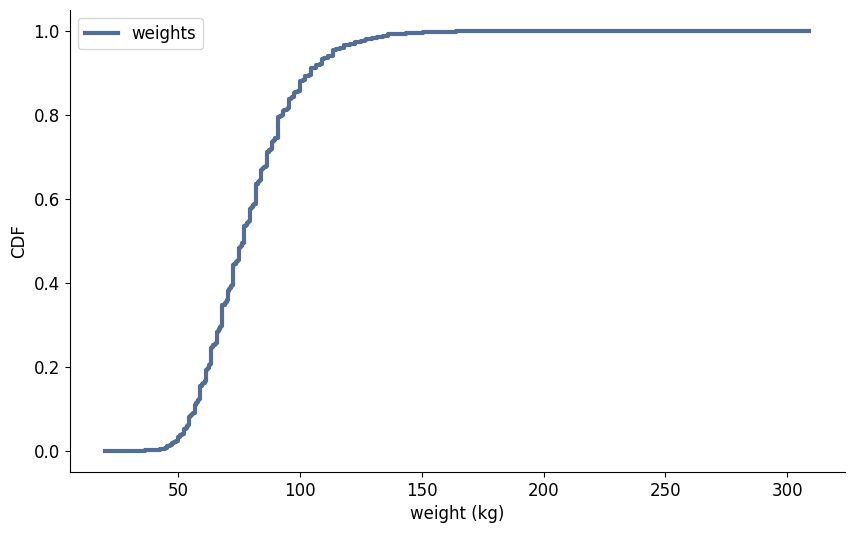

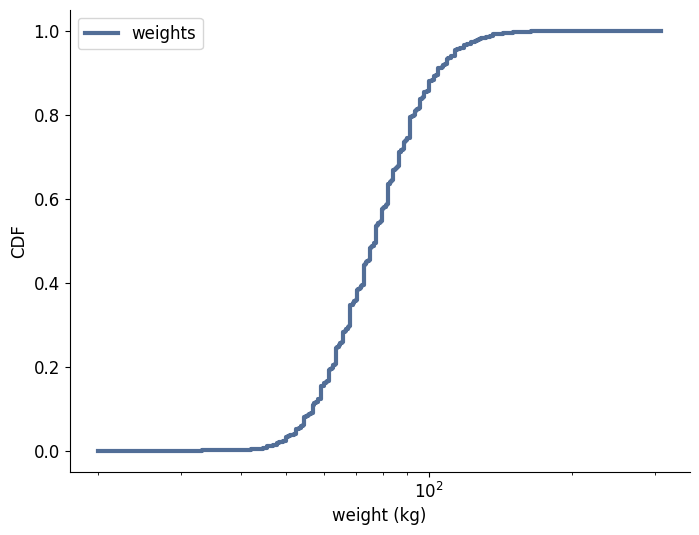

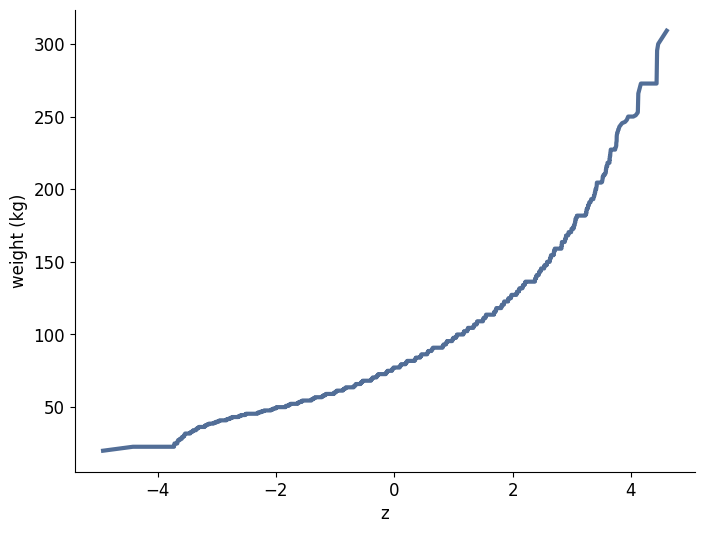

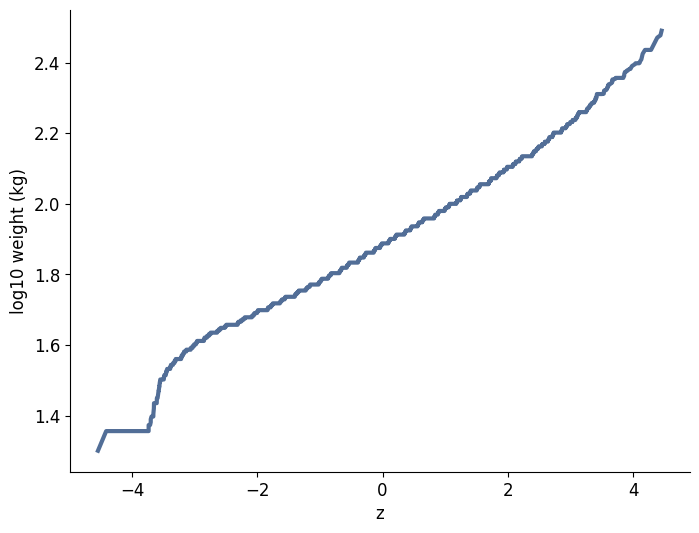

<Figure size 800x600 with 0 Axes>

In [23]:
# Book's original code: BRFSS adult weight analysis
# Requires: brfss.py, CDBRFS08.ASC.gz, thinkstats2.py, thinkplot.py

import brfss
import thinkstats2
import thinkplot

df = brfss.ReadBrfss(nrows=None)
weights = df.wtkg2.dropna()

# Figure 5-7 (left): linear scale + normal model
cdf = thinkstats2.Cdf(weights, label='weights')
thinkplot.Cdf(cdf)
# overlay normal model...
thinkplot.Show(xlabel='weight (kg)', ylabel='CDF')

# Figure 5-7 (right): log scale + lognormal model
thinkplot.Cdf(cdf)
thinkplot.Show(xlabel='weight (kg)', ylabel='CDF', xscale='log')

# Figure 5-8: Normal probability plots
# Left: raw weights
xs, ys = thinkstats2.NormalProbability(weights)
thinkplot.Plot(xs, ys)
thinkplot.Show(xlabel='z', ylabel='weight (kg)')

# Right: log-transformed weights
import numpy as np
log_weights = np.log10(weights)
xs, ys = thinkstats2.NormalProbability(log_weights)
thinkplot.Plot(xs, ys)
thinkplot.Show(xlabel='z', ylabel='log10 weight (kg)')


`brfss.ReadBrfss()` reads the BRFSS data file and returns a DataFrame with health survey variables. The `wtkg2` column contains weight in kilograms. The textbook shows that the lognormal model (right panel, log scale) fits better than the normal model (left panel, linear scale), and this is confirmed by the normal probability plots (Figure 5-8).


### A.5 Pareto Distribution -- City Populations (Figure 5-10)


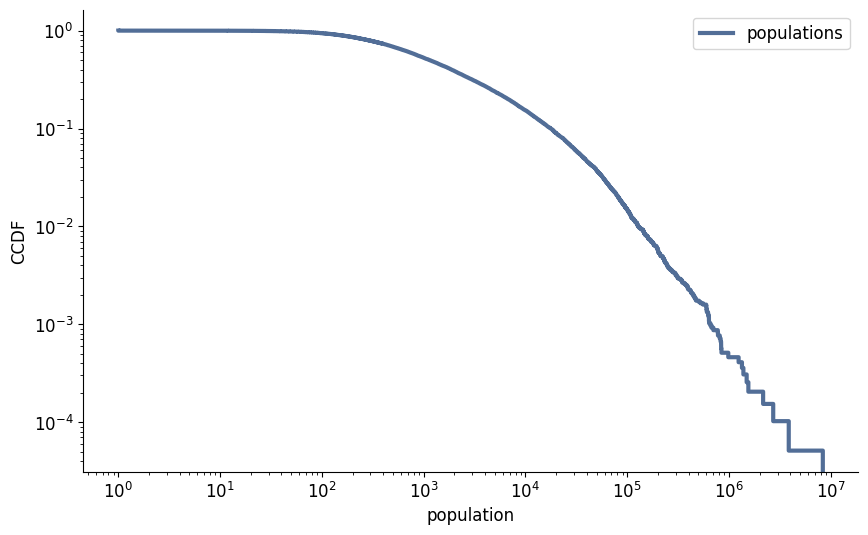

<Figure size 800x600 with 0 Axes>

In [24]:
# Book's original code: US city population analysis
# Requires: populations.py, PEP_2012_PEPANNRES_with_ann.csv, thinkstats2.py, thinkplot.py

import populations
import thinkstats2
import thinkplot

pops = populations.ReadData()
cdf = thinkstats2.Cdf(pops, label='populations')

# Figure 5-10: CCDF on log-log scale
thinkplot.Cdf(cdf, complement=True)
thinkplot.Show(xlabel='population',
               ylabel='CCDF',
               xscale='log',
               yscale='log')


`populations.ReadData()` reads the Census Bureau file and returns a list of city/town populations. Plotting the CCDF on a log-log scale reveals that the upper tail follows a Pareto distribution (straight line), while the body is better described by a lognormal model.


### A.6 Random Number Generation via Inverse CDF


In [25]:
# Book's original code: generating exponential random numbers
import random
import math

def expovariate(lam):
    p = random.random()
    x = -math.log(1-p) / lam
    return x

# Generate samples
lam = 2.0
samples = [expovariate(lam) for _ in range(1000)]
print(f"Mean: {sum(samples)/len(samples):.3f} (expected: {1/lam:.3f})")


Mean: 0.493 (expected: 0.500)


The textbook's `expovariate` function implements the inverse CDF method for the exponential distribution. The parameter is named `lam` (not `lambda`) because `lambda` is a reserved Python keyword. The function draws $p \sim \text{Uniform}(0, 1)$ and returns $x = -\log(1-p)/\lambda$.

---

*End of Appendix. The code above is provided for reference and requires the ThinkStats2 helper modules to execute.*
